# **Complete repository step-by-step diagnostics.**

In [1]:
from typing import Any, Callable, Optional
from rich import print
import yaml
from PIL import Image

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

def assert_true(condition: bool, message: str) -> bool:
    if not condition:
        raise AssertionError(message)
    return True

def set_layer(edge: Any, layer: int) -> Any:
    setattr(edge, "layer", layer)
    return edge

def assert_square_image(image: Image.Image) -> bool:
    return assert_true(image.width == image.height, "Image must be square.")

def load_yaml_config(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


## **Node** (in node.py)

[VALIDATED] Node(124.2, 8.2, 0): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 1): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 2): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 3): Executed successfully.

[VALIDATED] Node(124.2, 8.2, None): Executed successfully.

...

[REJECTED] Node(-181, 8.2, 0): Safely blocked with ValueError([NODE] Invalid lon value -181. Must be a number from 
-180 to 180.)

[REJECTED] Node(124.2, 91, 0): Safely blocked with ValueError([NODE] Invalid lat value 91. Must be a number from 
-90 to 90.)

[REJECTED] Node(124.2, -91, 0): Safely blocked with ValueError([NODE] Invalid lat value -91. Must be a number from 
-90 to 90.)

[VALIDATED] Node identity and immutability: Executed successfully.

[VALIDATED] Node visualization square image: Executed successfully.

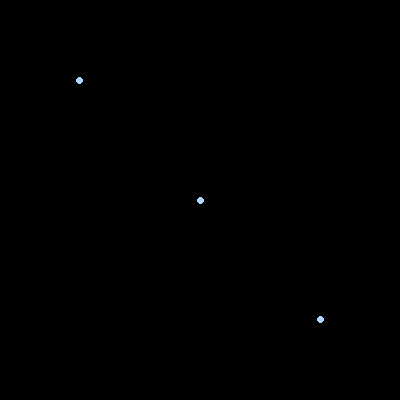

In [2]:
from utils.node import Node
from PIL import Image
from IPython.display import display

node_cases = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in node_cases:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        validate_call(label, expected, Node, lon, lat)
    else:
        validate_call(label, expected, Node, lon, lat, layer)

for lon, lat, layer in [(124.2, 8.2, 4), (124.2, 8.2, -1)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

for lon, lat, layer in [(181, 8.2, 0), (-181, 8.2, 0), (124.2, 91, 0), (124.2, -91, 0)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

def verify_node_contract() -> bool:
    n1 = Node(124.2, 8.2, 0)
    n2 = Node(124.2, 8.2, 0)

    assert_true(n1.id != n2.id, "Node IDs should be unique")
    assert_true(isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string")
    assert_true(n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved")

    try:
        n1.lon = 125.0
        raise AssertionError("Node.lon should be immutable")
    except AttributeError:
        pass

    try:
        n1.lat = 9.0
        raise AssertionError("Node.lat should be immutable")
    except AttributeError:
        pass

    return True

validate_call("Node identity and immutability", True, verify_node_contract)

img_node = Image.new("RGB", (400, 400), "black")
context = ((124.20, 8.30), (124.30, 8.20))
for node in [Node(124.22, 8.28, 0), Node(124.28, 8.22, 1), Node(124.25, 8.25, 2)]:
    node.draw(context, img_node)

validate_call("Node visualization square image", True, assert_square_image, img_node)
display(img_node)


## **DirEdge** (in directed_edge.py)

[VALIDATED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, 
Node(N892d79e23f624c69ba37fa160d2f03f2): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

[REJECTED] DirEdge(None, Node(N892d79e23f624c69ba37fa160d2f03f2): lon=124.243862, lat=8.237768, layer=1): Safely 
blocked with ValueError([DIR EDGE] No start node provided.)

[REJECTED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, None): Safely 
blocked with ValueError([DIR EDGE] No end node provided.)

[REJECTED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, 
Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

[REJECTED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, 
Node(N67edbfdf609641f8aab56c45901ff9ed): lon=124.243862, lat=8.237768, layer=0): Safely blocked with 
ValueError([DIR EDGE] Start and end nodes on different layers must have same coordinates.)

...

[VALIDATED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, 
Node(N892d79e23f624c69ba37fa160d2f03f2): lon=124.243862, lat=8.237768, layer=1): Executed successfully.

[VALIDATED] DirEdge type: Executed successfully.

[REJECTED] DirEdge(Node(N4f353e9898ca4562ac022373019f1f23): lon=124.2384, lat=8.2393, layer=3, 
Node(N4f353e9898ca4562ac022373019f1f23): lon=124.2384, lat=8.2393, layer=3): Safely blocked with ValueError([DIR 
EDGE] Start and end nodes cannot be identical.)

[REJECTED] DirEdge(Node(N080357aae18a40348c1cb90c06a46798): lon=124.2384, lat=8.2393, layer=1, 
Node(N67edbfdf609641f8aab56c45901ff9ed): lon=124.243862, lat=8.237768, layer=0): Safely blocked with 
ValueError([DIR EDGE] Start and end nodes on different layers must have same coordinates.)

[VALIDATED] DirEdge visualization square image: Executed successfully.

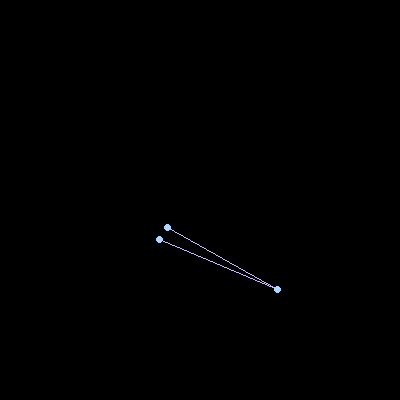

In [3]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from PIL import Image
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1)
n2l1 = Node(124.243862, 8.237768, 1)
n3l1 = Node(124.238, 8.239, 1)
n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)
n3l2 = Node(124.238, 8.239, 2)
n1l3 = Node(124.2384, 8.2393, 3)
n2l3 = Node(124.243862, 8.237768, 3)
n3l3 = Node(124.238, 8.239, 3)
n1l0 = Node(124.2384, 8.2393, 0)
n2l0 = Node(124.243862, 8.237768, 0)
n3l0 = Node(124.238, 8.239, 0)

dir_edge_cases = [
    (n1l1, n2l1, True),
    (None, n2l1, False),
    (n1l1, None, False),
    (n1l1, n1l1, False),
    (n1l1, n2l0, False),
]

for start_node, end_node, expected in dir_edge_cases:
    validate_call(f"DirEdge({start_node}, {end_node})", expected, DirEdge, start_node, end_node)

dir_edges_s = [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]
dir_edges_e = [DirEdge(n1l2, n2l2), DirEdge(n2l1, n2l2)]
validate_call("_stitch(dir_edges_s, dir_edges_e, weight=2)", True, _stitch, dir_edges_s, dir_edges_e, weight=2)
validate_call("Stitched edge connections", True, lambda: [edge.next_edges for edge in dir_edges_s + dir_edges_e])

validate_call("Great-circle distance", True, lambda: DirEdge(n1l1, n2l1).getLength())

for start_node, end_node, expected in [(n1l1, n2l1, True), (n1l3, n1l3, False), (n1l1, n2l0, False)]:
    dir_edge = validate_call(f"DirEdge({start_node}, {end_node})", expected, DirEdge, start_node, end_node)
    if dir_edge is not None:
        validate_call("DirEdge type", True, lambda edge=dir_edge: edge.getType())

img_edge = Image.new("RGB", (400, 400), "black")
context_edge = ((124.230, 8.245), (124.250, 8.235))
for edge in [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]:
    edge.draw(context_edge, img_edge)
for node in [n1l1, n2l1, n3l1]:
    node.draw(context_edge, img_edge)

validate_call("DirEdge visualization square image", True, assert_square_image, img_edge)
display(img_edge)


## **CityGraph** (in city_graph.py)

[REJECTED] BBOX Validation (Too Short): Safely blocked with ValueError([CITY GRAPH] Invalid bbox. Must be a tuple 
of 4 floats: (min_lat, max_lat, min_lon, max_lon).)

[VALIDATED] CityGraph Instance Creation: Executed successfully.

[VALIDATED] Valid Path A* (n1 -> n3): Executed successfully.

[REJECTED] Orphan Node Exception: Safely blocked with ValueError([CITY GRAPH] Start and end nodes must belong to 
this CityGraph instance.)

[VALIDATED] Visualization Return Type: Executed successfully.

[VALIDATED] Image Aspect Ratio Verification: Executed successfully.

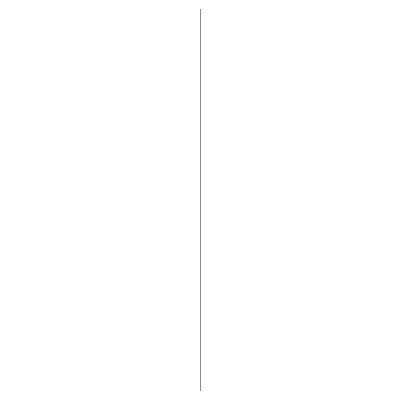

In [4]:
from utils.city_graph import CityGraph
from utils.node import Node
from utils.directed_edge import DirEdge

MOCK_BBOX = (8.22, 8.25, 124.23, 124.26)
LOCAL_PBF_PATH = "utils/data/iligan-city.pbf"

validate_call("BBOX Validation (Too Short)", False, CityGraph, bbox=(8.2,))
cg = validate_call(
    "CityGraph Instance Creation",
    True,
    CityGraph,
    bbox=MOCK_BBOX,
    name="DiagnosticGraph",
    pbf_path=LOCAL_PBF_PATH,
    use_api=False,
)

if cg:
    n1 = Node(124.24, 8.23)
    n2 = Node(124.24, 8.24)
    n3 = Node(124.24, 8.25)
    e1 = DirEdge(n1, n2, is_drivable=True)
    e2 = DirEdge(n2, n3, is_drivable=True)

    cg.nodes = [n1, n2, n3]
    cg.graph = [e1, e2]
    cg.stitch_graph()

    validate_call("Valid Path A* (n1 -> n3)", True, cg.find_shortest_path, n1, n3)
    n_rogue = Node(120.0, 10.0)
    validate_call("Orphan Node Exception", False, cg.find_shortest_path, n1, n_rogue)

    img = validate_call("Visualization Return Type", True, cg.draw, size=400)
    if img:
        validate_call("Image Aspect Ratio Verification", True, assert_square_image, img)
        display(img)

[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 138614.71it/s]


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] Iligan CityGraph Visualization: Executed successfully.

[VALIDATED] Iligan CityGraph Square Image: Executed successfully.

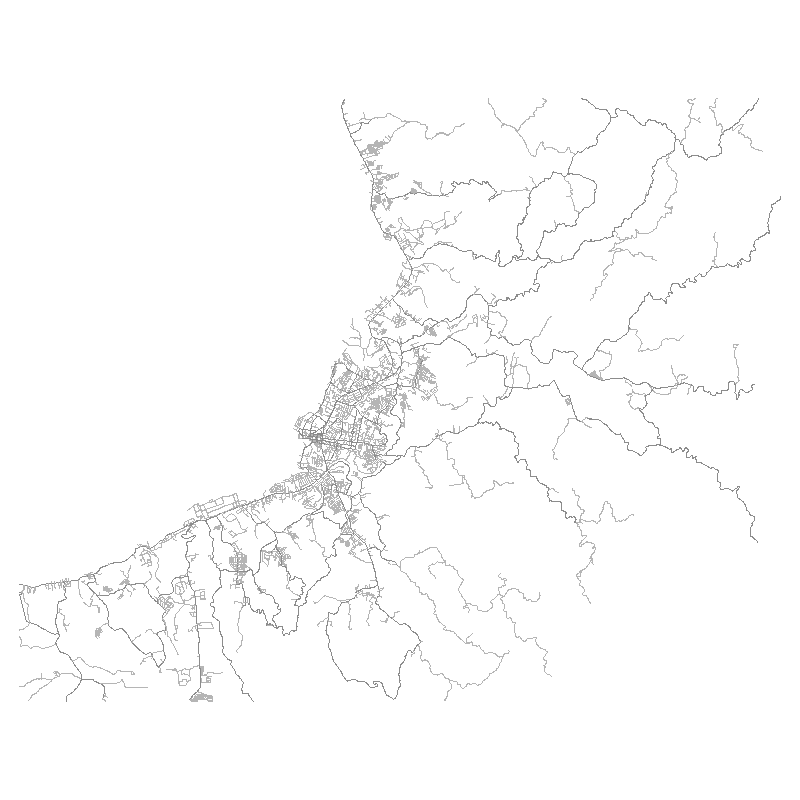

In [5]:
from importlib import reload
from IPython.display import display
import utils.city_graph as city_graph_module

city_graph_module = reload(city_graph_module)
CityGraph = city_graph_module.CityGraph

city_graph_cfg = load_yaml_config("configs/iligan_configs.yaml")["city_graph"]

iligan_city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
)

if iligan_city:
    iligan_img = validate_call(
        "Iligan CityGraph Visualization",
        True,
        iligan_city.draw,
        size=800,
        only_drivable=False,
    )

    if iligan_img:
        validate_call("Iligan CityGraph Square Image", True, assert_square_image, iligan_img)
        display(iligan_img)

## **DirectDemandSampler** (in direct_demand_sampler.py)

In [6]:
# prepare .env

import os
from dotenv import load_dotenv

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

if not TOMTOM_API_KEY:
    raise ValueError("[ENVIRONMENT] TOMTOM_API_KEY is missing from the .env file.")
else:
    validate_call("TOMTOM API key present", True, lambda: bool(TOMTOM_API_KEY))

[VALIDATED] TOMTOM API key present: Executed successfully.

In [7]:
# initialize citygraph

from utils.city_graph import CityGraph
from IPython.display import display
from rich import print


full_network_bbox = (8.1500, 8.3300, 124.1500, 124.4000)
explicit_coords = {
    "MSU-IIT": (8.2415, 124.2435),
    "Robinsons Place": (8.2175, 124.2380)
}

city = validate_call(
    "CityGraph initialization", 
    True, 
    CityGraph, 
    bbox=full_network_bbox,
    name="Iligan Full Sector",
    landmarks=explicit_coords,
    pbf_path="utils/data/iligan-city.pbf",
    verbose=True
)

if city:
    validate_call("CityGraph node count", True, lambda: len(city.nodes))


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 126392.96it/s]


[VALIDATED] CityGraph initialization: Executed successfully.

[VALIDATED] CityGraph node count: Executed successfully.

### Spatial Topology and API Token Economy

The base road network is parsed into a directed multi-graph. To execute inverse distance weighting on empirical TomTom traffic data without exhausting API quotas, we calculate a statistically valid sample size dynamically using Cochran's formula.

To achieve a 95% confidence level with a 5% margin of error across the finite population of total network nodes, the initial sample size $n_0$ is calculated as:

$$n_0 = \frac{Z^2 p q}{e^2}$$

Where $Z = 1.96$ (95% confidence level), $p = 0.5$ (maximum population variance), and $e = 0.05$ (5% acceptable margin of error). This yields $n_0 = 384$. 

Applying the finite population correction for the dynamically retrieved node count $N$:

$$n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}$$

The subsequent cell computes this exact value $n$ to restrict the API limits automatically, ensuring representative spatial accuracy while preserving transaction tokens.

*Source:* Cochran, W. G. (1977). *Sampling Techniques* (3rd ed.). John Wiley & Sons.

In [8]:
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig

cfg = load_yaml_config("configs/iligan_configs.yaml")

city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(cfg["city_graph"]["bbox"]),
    name=cfg["city_graph"]["name"],
    use_api=False
)


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] CityGraph with All Edges: Executed successfully.

[VALIDATED] CityGraph with Only Drivable Edges: Executed successfully.

All Edges vs. Only Drivable

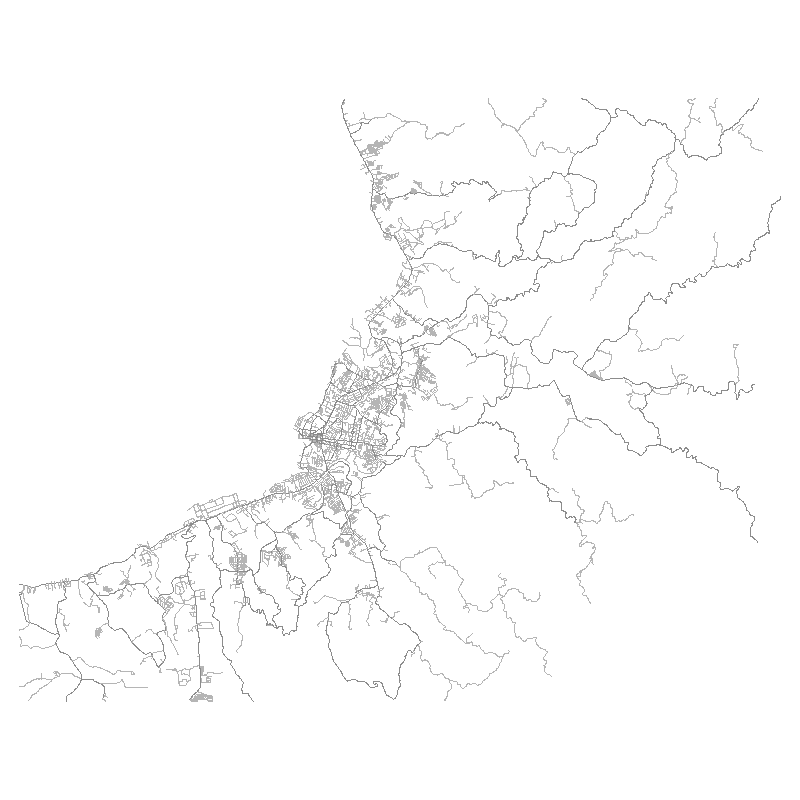

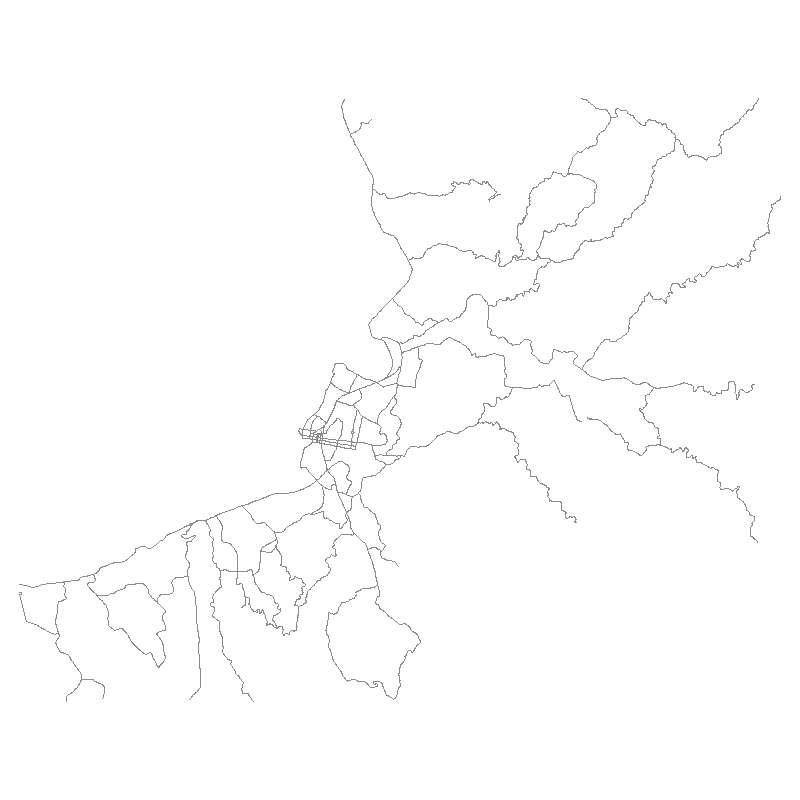

In [9]:
# Compare CityGraph rendering with all edges vs. only drivable edges
if city:
    # Render with all edges
    all_edges_img = validate_call(
        "CityGraph with All Edges",
        True,
        city.draw,
        size=800,
        only_drivable=False
    )
    
    # Render with only drivable edges
    drivable_only_img = validate_call(
        "CityGraph with Only Drivable Edges",
        True,
        city.draw,
        size=800,
        only_drivable=True
    )
    
    # Display both images
    if all_edges_img and drivable_only_img:
        from IPython.display import display
        print("[bold cyan]All Edges vs. Only Drivable[/bold cyan]")
        display(all_edges_img)
        display(drivable_only_img)


## **Route** (in route.py)

In [10]:
import copy
from utils.node import Node
from utils.directed_edge import DirEdge
from utils.route import Route

class MockCityGraph:
    pass

cg = MockCityGraph()

n1 = Node(124.2, 8.2, 2)
n2 = Node(124.3, 8.2, 2)
n3 = Node(124.3, 8.3, 2)
n4 = Node(124.2, 8.3, 2)
n_rogue = Node(0.0, 0.0, 2)

e1 = set_layer(DirEdge(n1, n2, weight=10), 2)
e2 = set_layer(DirEdge(n2, n3, weight=10), 2)
e3 = set_layer(DirEdge(n3, n4, weight=10), 2)
e4 = set_layer(DirEdge(n4, n1, weight=10), 2)
e1.next_edges = [e2]; e2.next_edges = [e3]; e3.next_edges = [e4]; e4.next_edges = [e1]

base_path = [e1, e2, e3, e4]

valid_path = copy.deepcopy(base_path)
open_path = copy.deepcopy(base_path)[:-1]

broken_path = copy.deepcopy(base_path)
broken_path[1] = set_layer(DirEdge(n_rogue, n3, weight=10), 2)

layer_path = copy.deepcopy(base_path)
set_layer(layer_path[2], 1)

branching_path = copy.deepcopy(base_path)
rogue_edge = set_layer(DirEdge(n2, n_rogue, weight=10), 2)
branching_path[0].next_edges.append(rogue_edge)

route_cases = [
    ("Valid Looping Route", True, valid_path),
    ("Open Loop Violation", False, open_path),
    ("Contiguity Violation", False, broken_path),
    ("Layer Restriction Violation", False, layer_path),
    ("Branching Violation", False, branching_path),
]

for label, expected, path in route_cases:
    validate_call(label, expected, Route, cg, path)


[VALIDATED] Valid Looping Route: Executed successfully.

[REJECTED] Open Loop Violation: Safely blocked with ValueError([ROUTE] Path fails to loop. Terminal edge must 
connect to initial edge.)

[REJECTED] Contiguity Violation: Safely blocked with ValueError([ROUTE] Contiguity broken at index 0. Edges do not 
form a continuous sequence.)

[REJECTED] Layer Restriction Violation: Safely blocked with ValueError([ROUTE] Invalid edge layer. Edge 
N25c6528996f14f07bea01a0eaf0c3143N01cfda015f5a44dfa50a5b57eacb8d9c does not belong strictly to Layer 2.)

[REJECTED] Branching Violation: Safely blocked with ValueError([ROUTE] Branching violation. Edge 
Ne447cbfdf0bb47d6a3872ef5dbaeca98N321cb3d2faaf415486cfc65c90eb0a5e must have exactly one outgoing Layer 2 edge. 
Found 2.)

[VALIDATED] Initialize DDM Sampler: Executed successfully.

[VALIDATED] Initialize RouteGenerator: Executed successfully.

[REJECTED] Minimum Points Violation: Safely blocked with ValueError([ROUTE GENERATOR] Minimum of 2 points required 
to generate a route.)

[VALIDATED] Render Iligan Base Map: Executed successfully.

[VALIDATED] Calculate Iligan Bounding Context: Executed successfully.

...

[VALIDATED] Render Frame 8: Executed successfully.

[VALIDATED] Render Frame 9: Executed successfully.

[VALIDATED] Render Frame 10: Executed successfully.

[VALIDATED] Compile Route Cycle GIF: Executed successfully.

[VALIDATED] Verify GIF Return Type: Executed successfully.

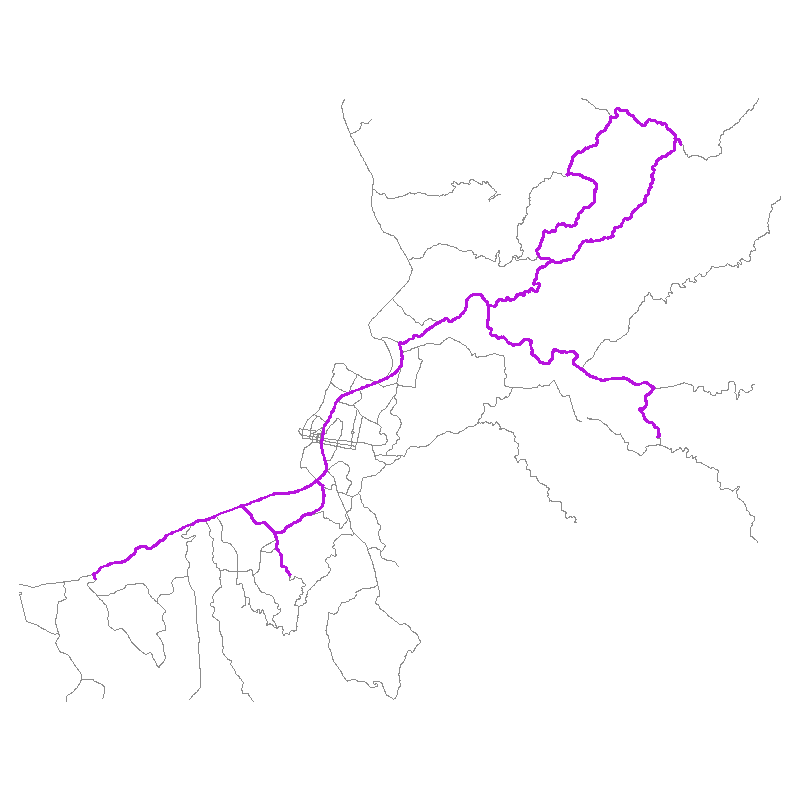

In [11]:
from utils.route import RouteGenerator
from IPython.display import display, Image as IPyImage
from utils.route import RouteGenerator
from utils.visualization import draw_all, compile_to_gif

if cfg:
    if city:
        sampler = validate_call(
            "Initialize DDM Sampler",
            True,
            DirectDemandSampler,
            city=city,
            config=DDMConfig(**cfg["ddm"]),
            only_drivable=True
        )
        
        if sampler:
            generator = validate_call(
                "Initialize RouteGenerator",
                True,
                RouteGenerator,
                city_graph=city,
                sampler=sampler
            )
            
            if generator:
                validate_call("Minimum Points Violation", False, generator.generate, n_points=1)
                
                base_img = validate_call("Render Iligan Base Map", True, city.draw, size=800, only_drivable=True)
                context = validate_call("Calculate Iligan Bounding Context", True, city.get_bounds)
                
                if base_img and context:
                    routes = []
                    for i in range(10):
                        route = validate_call(f"Generate Route {i+1}", True, generator.generate, n_points=5)
                        if route:
                            routes.append(route)
                    
                    if routes:
                        frames = []
                        for i, route in enumerate(routes):
                            frame = validate_call(
                                f"Render Frame {i+1}",
                                True,
                                draw_all,
                                drawable_objects=[route],
                                context=context,
                                base_image=base_img
                            )
                            if frame:
                                frames.append(frame)
                        
                        if frames:
                            gif_stream = validate_call(
                                "Compile Route Cycle GIF",
                                True,
                                compile_to_gif,
                                frames=frames,
                                fps=4,
                                export_to=None
                            )
                            
                            if gif_stream:
                                validate_call(
                                    "Verify GIF Return Type", 
                                    True, 
                                    lambda: isinstance(gif_stream, bytes) or exec('raise TypeError("Expected bytes stream.")')
                                )
                                display(IPyImage(data=gif_stream, format="gif"))